In [1]:
"""
Sensitivity Analysis of EKF Hyperparameters (Q_sigma, R_sigma)
for Blind Adaptive Signal Quantization via Suprathreshold Stochastic Resonance

Scalar weight case with Gaussian input signal.
Analyzes how different Q_sigma and R_sigma affect:
  - Convergence speed
  - Steady-state MSE
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'text.usetex': False,
})

# ============================================================
# Core functions
# ============================================================

def ssr_quantize(x, N_comp, noise_std, delta=1.0):
    """
    Suprathreshold stochastic resonance (SSR) array quantizer.
    N_comp comparators, each adds independent noise eta_i ~ N(0, noise_std^2).
    Output = (1/N) * sum of sign(x + eta_i), scaled by delta.
    Returns the quantized output (scalar).
    """
    eta = np.random.randn(N_comp) * noise_std
    bits = np.sign(x + eta)          # +1 / -1
    return delta * np.mean(bits)


def g_func(x, noise_std, N_comp, delta=1.0):
    """
    Expected SSR output E[q | x] = delta * (2*Phi(x/noise_std) - 1)
    where Phi is the standard normal CDF.
    For large N_comp this is the deterministic transfer function.
    """
    from scipy.special import erf
    return delta * erf(x / (noise_std * np.sqrt(2)))


def g_prime(x, noise_std, delta=1.0):
    """
    Derivative dg/dx = delta * (2/noise_std) * phi(x/noise_std)
    where phi is the standard normal PDF.
    """
    return delta * (2.0 / (noise_std * np.sqrt(2 * np.pi))) * np.exp(-x**2 / (2 * noise_std**2))


def run_ekf_scalar(w_true, N_iter, Q_sigma, R_sigma,
                   N_comp=64, noise_std=0.8, delta=1.0,
                   input_std=1.0, seed=None):
    """
    Run EKF to estimate scalar weight w from SSR-quantized observations.

    Model:
        State:   w_k = w_{k-1} + process_noise,   process_noise ~ N(0, Q_sigma)
        Obs:     y_k = g(w_k * s_k) + meas_noise, meas_noise ~ N(0, R_sigma)
        where g(.) is the SSR transfer function, s_k ~ N(0, input_std^2).

    Returns:
        w_est_history: array of shape (N_iter,) — estimated weight at each step
        mse_history:   array of shape (N_iter,) — instantaneous squared error
    """
    if seed is not None:
        np.random.seed(seed)

    # --- Initialisation ---
    w_hat = 0.0          # initial estimate (deliberately far from truth)
    P = 1.0              # initial error covariance

    w_est_history = np.zeros(N_iter)
    sq_err_history = np.zeros(N_iter)

    for k in range(N_iter):
        # Input signal
        s_k = np.random.randn() * input_std

        # True quantized observation
        y_k = ssr_quantize(w_true * s_k, N_comp, noise_std, delta)

        # ----- EKF Predict -----
        w_pred = w_hat                     # state transition is identity
        P_pred = P + Q_sigma               # add process noise covariance

        # ----- EKF Update -----
        # Predicted observation: g(w_pred * s_k)
        y_pred = g_func(w_pred * s_k, noise_std, N_comp, delta)

        # Jacobian H_k = dg/dw = g'(w*s) * s
        H_k = g_prime(w_pred * s_k, noise_std, delta) * s_k

        # Innovation
        innov = y_k - y_pred

        # Innovation covariance
        S_k = H_k * P_pred * H_k + R_sigma

        # Kalman gain
        K_k = P_pred * H_k / S_k

        # State update
        w_hat = w_pred + K_k * innov

        # Covariance update (Joseph form for numerical stability)
        P = (1 - K_k * H_k) * P_pred

        # Record
        w_est_history[k] = w_hat
        sq_err_history[k] = (w_hat - w_true) ** 2

    return w_est_history, sq_err_history


# ============================================================
# Monte-Carlo averaging helper
# ============================================================

def mc_run(w_true, N_iter, Q_sigma, R_sigma, N_mc=50, **kwargs):
    """Run N_mc independent trials and return mean squared error curve."""
    all_se = np.zeros((N_mc, N_iter))
    all_west = np.zeros((N_mc, N_iter))
    for m in range(N_mc):
        w_est, se = run_ekf_scalar(w_true, N_iter, Q_sigma, R_sigma,
                                    seed=1000*m + int(Q_sigma*1e6) % 999 + int(R_sigma*1e6) % 999,
                                    **kwargs)
        all_se[m] = se
        all_west[m] = w_est
    mse_curve = np.mean(all_se, axis=0)
    mean_west = np.mean(all_west, axis=0)
    return mse_curve, mean_west


# ============================================================
# Experiment parameters
# ============================================================

w_true = 2.0          # true scalar weight
N_iter = 2000         # iterations
N_mc   = 80           # Monte-Carlo runs for averaging
N_comp = 64           # number of SSR comparators
noise_std = 0.8       # SSR noise level
input_std = 1.0       # Gaussian input std

# Baseline
Q0 = 1e-3
R0 = 1.0

# ============================================================
# (A) Sensitivity to Q_sigma  (fix R_sigma = R0)
# ============================================================
Q_values = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
Q_labels = [r'$Q_\sigma=10^{-5}$', r'$Q_\sigma=10^{-4}$',
            r'$Q_\sigma=10^{-3}$', r'$Q_\sigma=10^{-2}$',
            r'$Q_\sigma=10^{-1}$']

print("=== Sensitivity to Q_sigma ===")
mse_Q = {}
for Q in Q_values:
    print(f"  Running Q_sigma={Q:.1e}, R_sigma={R0:.1e} ...")
    mse_Q[Q], _ = mc_run(w_true, N_iter, Q, R0, N_mc=N_mc,
                          N_comp=N_comp, noise_std=noise_std, input_std=input_std)

# ============================================================
# (B) Sensitivity to R_sigma  (fix Q_sigma = Q0)
# ============================================================
R_values = [1e-1, 5e-1, 1.0, 5.0, 10.0]
R_labels = [r'$R_\sigma=0.1$', r'$R_\sigma=0.5$',
            r'$R_\sigma=1.0$', r'$R_\sigma=5.0$',
            r'$R_\sigma=10$']

print("=== Sensitivity to R_sigma ===")
mse_R = {}
for R in R_values:
    print(f"  Running Q_sigma={Q0:.1e}, R_sigma={R:.1e} ...")
    mse_R[R], _ = mc_run(w_true, N_iter, Q0, R, N_mc=N_mc,
                          N_comp=N_comp, noise_std=noise_std, input_std=input_std)

# ============================================================
# (C) Compute summary statistics
# ============================================================
steady_start = int(N_iter * 0.8)   # last 20% for steady-state MSE

def convergence_iter(mse_curve, threshold=0.01):
    """First iteration where MSE drops below threshold and stays below."""
    below = mse_curve < threshold
    for i in range(len(below)):
        if below[i:min(i+50, len(below))].all():
            return i
    return N_iter  # did not converge

print("\n========== Summary Table: Q_sigma sensitivity ==========")
print(f"{'Q_sigma':>12s} | {'Steady-state MSE':>18s} | {'Conv. iter (MSE<0.01)':>22s}")
print("-" * 60)
for Q, lab in zip(Q_values, Q_labels):
    ss_mse = np.mean(mse_Q[Q][steady_start:])
    c_iter = convergence_iter(mse_Q[Q])
    print(f"{Q:12.1e} | {ss_mse:18.6f} | {c_iter:22d}")

print("\n========== Summary Table: R_sigma sensitivity ==========")
print(f"{'R_sigma':>12s} | {'Steady-state MSE':>18s} | {'Conv. iter (MSE<0.01)':>22s}")
print("-" * 60)
for R, lab in zip(R_values, R_labels):
    ss_mse = np.mean(mse_R[R][steady_start:])
    c_iter = convergence_iter(mse_R[R])
    print(f"{R:12.1e} | {ss_mse:18.6f} | {c_iter:22d}")


# ============================================================
# Plotting
# ============================================================

colors_Q = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#66a61e']
colors_R = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#66a61e']

fig, axes = plt.subplots(2, 2, figsize=(13, 9.5))

# --- (a) MSE convergence vs Q_sigma ---
ax = axes[0, 0]
for Q, lab, c in zip(Q_values, Q_labels, colors_Q):
    # smooth for readability
    win = 20
    smoothed = np.convolve(mse_Q[Q], np.ones(win)/win, mode='valid')
    ax.semilogy(np.arange(len(smoothed)), smoothed, label=lab, color=c, linewidth=1.3)
ax.set_xlabel('Iteration $k$')
ax.set_ylabel('MSE (log scale)')
ax.set_title(r'(a) MSE vs iteration — varying $Q_\sigma$ (fixed $R_\sigma=1.0$)')
ax.legend(loc='upper right')
ax.set_xlim([0, N_iter])
ax.grid(True, alpha=0.3)

# --- (b) Steady-state MSE bar chart vs Q_sigma ---
ax = axes[0, 1]
ss_mse_Q = [np.mean(mse_Q[Q][steady_start:]) for Q in Q_values]
conv_Q   = [convergence_iter(mse_Q[Q]) for Q in Q_values]
x_pos = np.arange(len(Q_values))
bars = ax.bar(x_pos, ss_mse_Q, color=colors_Q, width=0.6, edgecolor='k', linewidth=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'$10^{{{int(np.log10(Q))}}}$' for Q in Q_values])
ax.set_xlabel(r'$Q_\sigma$')
ax.set_ylabel('Steady-state MSE')
ax.set_title(r'(b) Steady-state MSE vs $Q_\sigma$')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')
# annotate convergence iteration
for i, (b, ci) in enumerate(zip(bars, conv_Q)):
    ax.text(b.get_x() + b.get_width()/2, b.get_height()*1.3,
            f'conv@{ci}', ha='center', va='bottom', fontsize=8)

# --- (c) MSE convergence vs R_sigma ---
ax = axes[1, 0]
for R, lab, c in zip(R_values, R_labels, colors_R):
    win = 20
    smoothed = np.convolve(mse_R[R], np.ones(win)/win, mode='valid')
    ax.semilogy(np.arange(len(smoothed)), smoothed, label=lab, color=c, linewidth=1.3)
ax.set_xlabel('Iteration $k$')
ax.set_ylabel('MSE (log scale)')
ax.set_title(r'(c) MSE vs iteration — varying $R_\sigma$ (fixed $Q_\sigma=10^{-3}$)')
ax.legend(loc='upper right')
ax.set_xlim([0, N_iter])
ax.grid(True, alpha=0.3)

# --- (d) Steady-state MSE bar chart vs R_sigma ---
ax = axes[1, 1]
ss_mse_R = [np.mean(mse_R[R][steady_start:]) for R in R_values]
conv_R   = [convergence_iter(mse_R[R]) for R in R_values]
x_pos = np.arange(len(R_values))
bars = ax.bar(x_pos, ss_mse_R, color=colors_R, width=0.6, edgecolor='k', linewidth=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels([str(R) for R in R_values])
ax.set_xlabel(r'$R_\sigma$')
ax.set_ylabel('Steady-state MSE')
ax.set_title(r'(d) Steady-state MSE vs $R_\sigma$')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')
for i, (b, ci) in enumerate(zip(bars, conv_R)):
    ax.text(b.get_x() + b.get_width()/2, b.get_height()*1.3,
            f'conv@{ci}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()

print("\nSaved: fig_sensitivity_main.png / .pdf")


# ============================================================
# Figure 2: 2-D heat-map  Q_sigma x R_sigma -> steady-state MSE
# ============================================================
print("\n=== 2-D grid: Q_sigma x R_sigma ===")
Q_grid = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
R_grid = [0.1, 0.5, 1.0, 5.0, 10.0]
N_mc_grid = 40  # fewer MC runs for the grid to save time

ss_mse_grid = np.zeros((len(Q_grid), len(R_grid)))
conv_grid   = np.zeros((len(Q_grid), len(R_grid)))

for i, Q in enumerate(Q_grid):
    for j, R in enumerate(R_grid):
        print(f"  Q={Q:.1e}, R={R:.1e} ...")
        mse_curve, _ = mc_run(w_true, N_iter, Q, R, N_mc=N_mc_grid,
                               N_comp=N_comp, noise_std=noise_std, input_std=input_std)
        ss_mse_grid[i, j] = np.mean(mse_curve[steady_start:])
        conv_grid[i, j] = convergence_iter(mse_curve)

fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))

# (a) Steady-state MSE heatmap
ax = axes2[0]
im = ax.imshow(np.log10(ss_mse_grid), aspect='auto', cmap='RdYlGn_r',
               origin='lower')
ax.set_xticks(range(len(R_grid)))
ax.set_xticklabels([str(r) for r in R_grid])
ax.set_yticks(range(len(Q_grid)))
ax.set_yticklabels([f'$10^{{{int(np.log10(q))}}}$' for q in Q_grid])
ax.set_xlabel(r'$R_\sigma$')
ax.set_ylabel(r'$Q_\sigma$')
ax.set_title(r'(a) $\log_{10}$(Steady-state MSE)')
# annotate cells
for i in range(len(Q_grid)):
    for j in range(len(R_grid)):
        val = ss_mse_grid[i, j]
        ax.text(j, i, f'{val:.4f}', ha='center', va='center', fontsize=8,
                color='white' if np.log10(val) > -1.5 else 'black')
cb = fig2.colorbar(im, ax=ax, shrink=0.85)
cb.set_label(r'$\log_{10}$(MSE)')

# (b) Convergence iteration heatmap
ax = axes2[1]
im2 = ax.imshow(conv_grid, aspect='auto', cmap='YlOrRd', origin='lower')
ax.set_xticks(range(len(R_grid)))
ax.set_xticklabels([str(r) for r in R_grid])
ax.set_yticks(range(len(Q_grid)))
ax.set_yticklabels([f'$10^{{{int(np.log10(q))}}}$' for q in Q_grid])
ax.set_xlabel(r'$R_\sigma$')
ax.set_ylabel(r'$Q_\sigma$')
ax.set_title(r'(b) Convergence iteration (MSE $< 0.01$)')
for i in range(len(Q_grid)):
    for j in range(len(R_grid)):
        val = int(conv_grid[i, j])
        ax.text(j, i, f'{val}', ha='center', va='center', fontsize=8,
                color='white' if val > 800 else 'black')
cb2 = fig2.colorbar(im2, ax=ax, shrink=0.85)
cb2.set_label('Iterations')

plt.tight_layout()

print("Saved: fig_sensitivity_heatmap.png / .pdf")


# ============================================================
# Figure 3: Weight trajectory examples (best, baseline, worst)
# ============================================================
fig3, axes3 = plt.subplots(1, 3, figsize=(14, 4))

scenarios = [
    (1e-3, 1.0,  'Baseline ($Q_\\sigma=10^{-3}$, $R_\\sigma=1.0$)'),
    (1e-1, 1.0,  'Large $Q_\\sigma$ ($Q_\\sigma=10^{-1}$, $R_\\sigma=1.0$)'),
    (1e-3, 10.0, 'Large $R_\\sigma$ ($Q_\\sigma=10^{-3}$, $R_\\sigma=10$)'),
]

for idx, (Q, R, title) in enumerate(scenarios):
    ax = axes3[idx]
    # Show 5 individual trajectories + mean
    for m in range(5):
        w_est, _ = run_ekf_scalar(w_true, N_iter, Q, R,
                                   N_comp=N_comp, noise_std=noise_std,
                                   input_std=input_std, seed=2000+m)
        ax.plot(w_est, color='steelblue', alpha=0.3, linewidth=0.7)

    _, mean_w = mc_run(w_true, N_iter, Q, R, N_mc=N_mc,
                        N_comp=N_comp, noise_std=noise_std, input_std=input_std)
    ax.plot(mean_w, color='darkred', linewidth=1.8, label='MC mean')
    ax.axhline(w_true, color='k', linestyle='--', linewidth=1, label=f'$w^*={w_true}$')
    ax.set_xlabel('Iteration $k$')
    if idx == 0:
        ax.set_ylabel('Estimated weight $\\hat{w}_k$')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim([0, N_iter])
    ax.grid(True, alpha=0.3)

plt.tight_layout()

print("Saved: fig_sensitivity_trajectories.png / .pdf")

print("\n✅ All figures generated successfully!")

=== Sensitivity to Q_sigma ===
  Running Q_sigma=1.0e-05, R_sigma=1.0e+00 ...
  Running Q_sigma=1.0e-04, R_sigma=1.0e+00 ...
  Running Q_sigma=1.0e-03, R_sigma=1.0e+00 ...
  Running Q_sigma=1.0e-02, R_sigma=1.0e+00 ...
  Running Q_sigma=1.0e-01, R_sigma=1.0e+00 ...
=== Sensitivity to R_sigma ===
  Running Q_sigma=1.0e-03, R_sigma=1.0e-01 ...
  Running Q_sigma=1.0e-03, R_sigma=5.0e-01 ...
  Running Q_sigma=1.0e-03, R_sigma=1.0e+00 ...
  Running Q_sigma=1.0e-03, R_sigma=5.0e+00 ...
  Running Q_sigma=1.0e-03, R_sigma=1.0e+01 ...

========== Summary Table: Q_sigma sensitivity ==========
     Q_sigma |   Steady-state MSE |  Conv. iter (MSE<0.01)
------------------------------------------------------------
     1.0e-05 |           0.015243 |                   2000
     1.0e-04 |           0.002133 |                   1192
     1.0e-03 |           0.000855 |                    472
     1.0e-02 |           0.002518 |                    189
     1.0e-01 |           0.008797 |                   

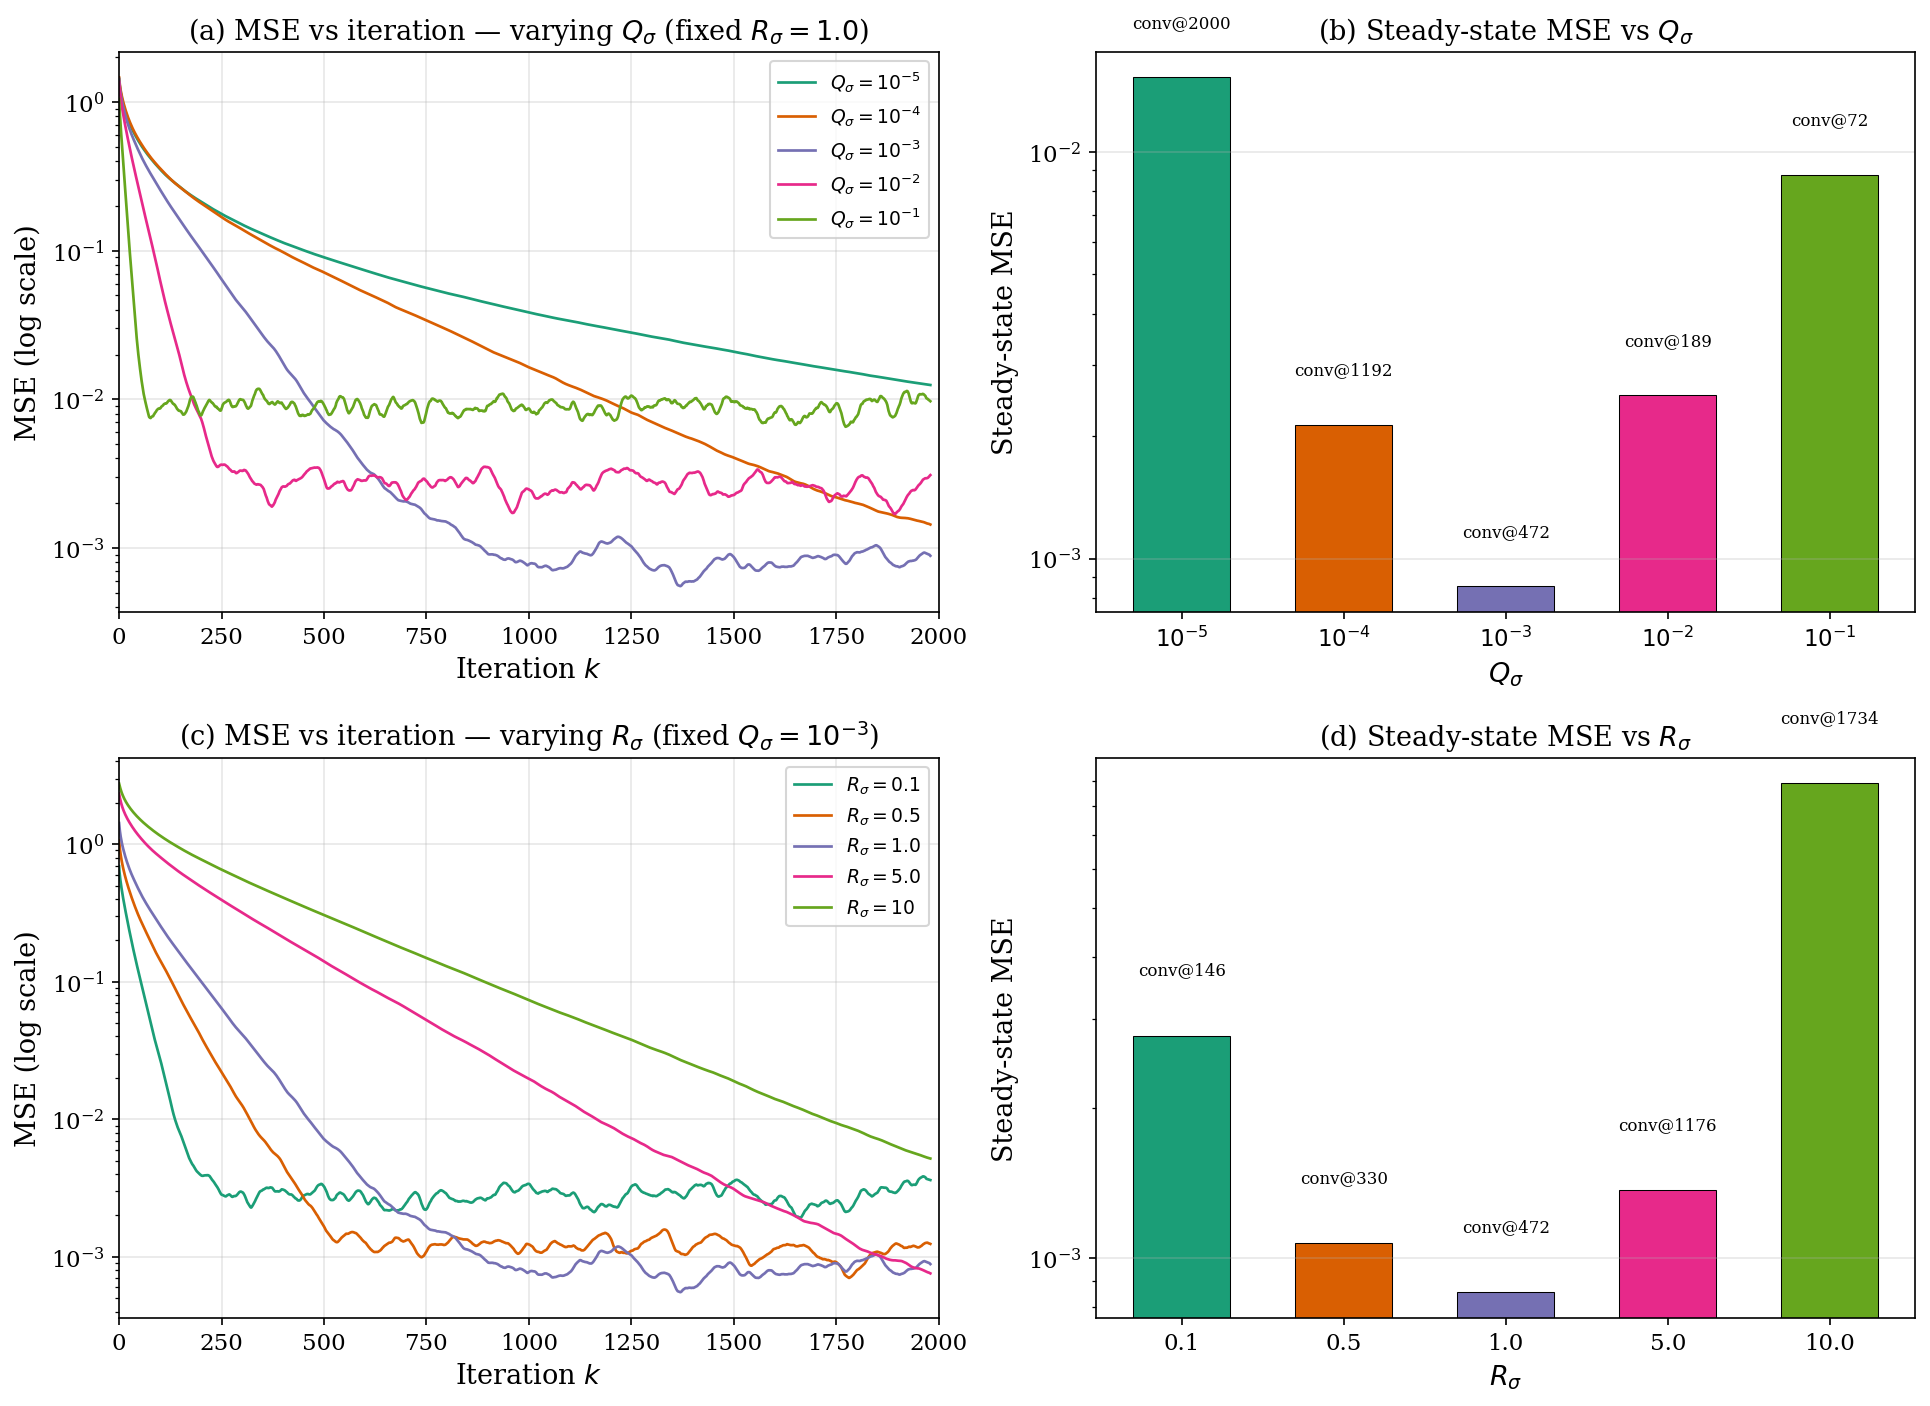

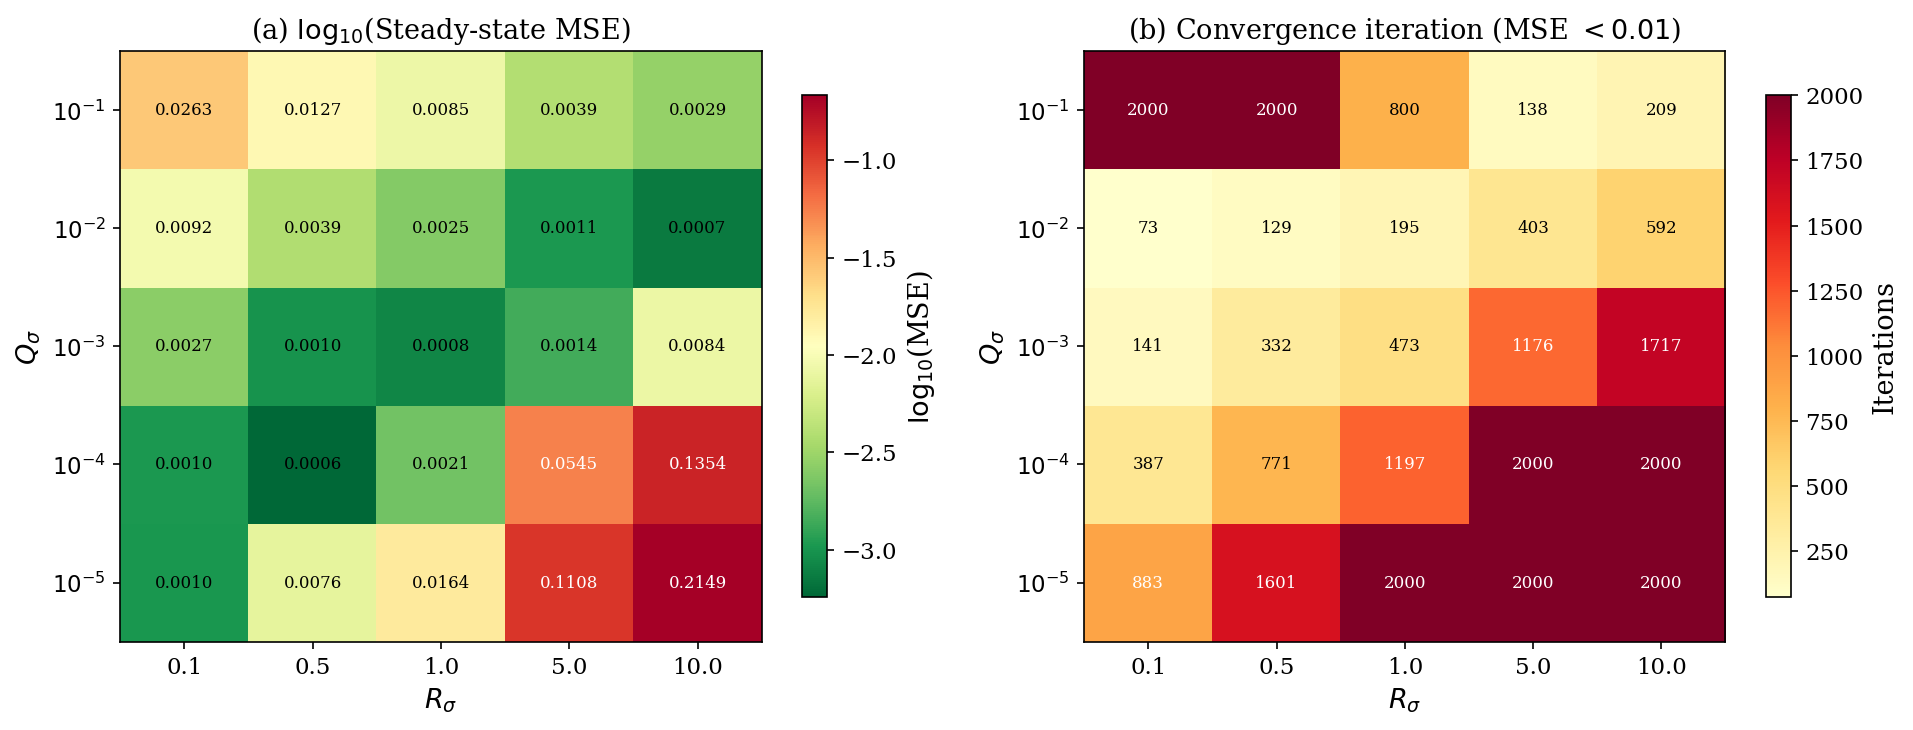

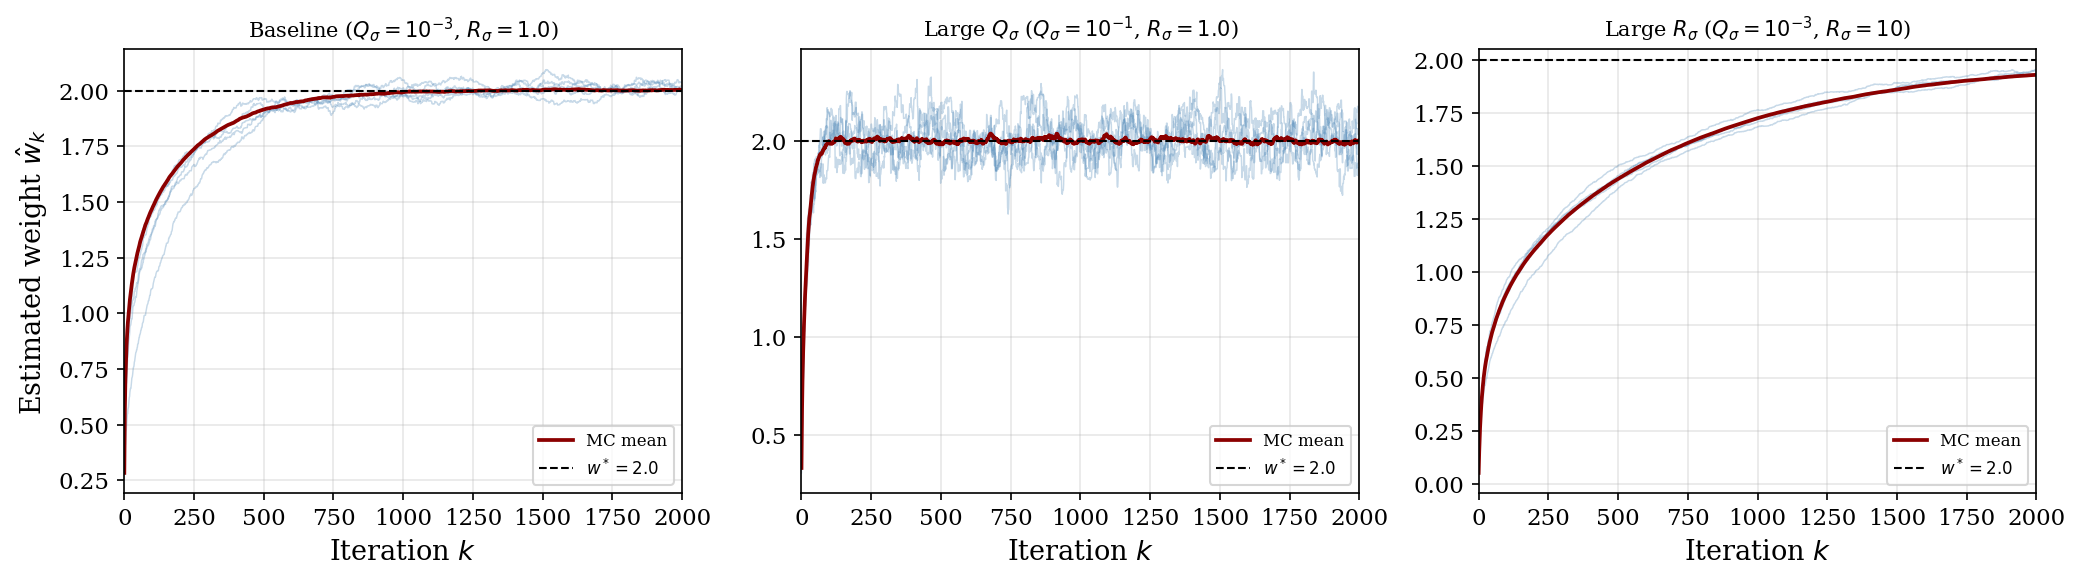

In [5]:
"""
Pareto Front: Performance vs Complexity — PyTorch Implementation
================================================================
Faithfully follows the user's three algorithm structures:
  (A) Vector weight RLS (N×1) + scalar EKF-σ
  (B) Scalar weight RLS (1×1) + scalar EKF-σ
  (C) Grouped weight RLS (M×1, with thresholds) + scalar EKF-σ

Weight update: RLS (not EKF)
  y_hat = w^T * sign(x + noise)   — weight applied AFTER quantization
  
Sigma update: scalar EKF
  H_k = -sum(w) * 2x/σ² * φ(x/σ)  — Jacobian of output w.r.t. σ
"""

import torch
import numpy as np
import time
import math

def gaussian_pdf(u):
    """Standard Gaussian PDF: φ(u) = (1/√(2π)) * exp(-u²/2)"""
    return (1.0 / math.sqrt(2 * math.pi)) * torch.exp(-0.5 * u**2)


# ====================================================================
# Algorithm 1: Vector weight (N_adapt × 1) + scalar EKF-σ
# ====================================================================
def run_vector_rls_ekf(input_data, N_adapt, true_sigma, Nx_total,
                       init_sigma=0.4, seed_val=42, Q_sigma=1e-4, R_sigma=0.1):
    """
    Vector weight RLS + scalar EKF for sigma.
    w ∈ R^{N_adapt}, updated by RLS.
    sigma updated by scalar EKF.
    """
    # RLS init
    w_adpt = torch.ones(N_adapt, 1) / N_adapt
    P_rls = torch.eye(N_adapt) * 10.0

    # EKF-sigma init
    sigma_curr = init_sigma
    P_sigma = 0.05
    sigma_min = 0.03

    # Recording
    sigma_history = torch.zeros(Nx_total)
    y_hat_history = torch.zeros(Nx_total)
    mse_history = torch.zeros(Nx_total)

    t0 = time.perf_counter()

    for k in range(Nx_total):
        x_k = input_data[k, 0]

        # 1. Array output
        torch.manual_seed(seed_val + 3 * k)
        noise_vec = true_sigma * torch.randn(N_adapt, 1)  # TRUE sigma for data generation
        y_vec = torch.sign(x_k + noise_vec)

        # 2. RLS Kalman gain
        denom = y_vec.T @ P_rls @ y_vec + 0.1
        g_rls = (P_rls @ y_vec) / denom

        # 3. Predicted output
        y_hat_k = (w_adpt.T @ y_vec).item()
        e_k = x_k - y_hat_k

        # 4. Update weight vector
        w_adpt = w_adpt + g_rls * e_k
        P_rls = P_rls - g_rls @ y_vec.T @ P_rls

        # 5. EKF predict sigma
        sigma_pred = sigma_curr
        P_sigma_pred = P_sigma + Q_sigma

        # 6. Jacobian H_k = -sum(w) * 2x/σ² * φ(x/σ)
        sum_w = torch.sum(w_adpt)
        s_safe = max(sigma_pred, 0.01)
        u = x_k / s_safe
        pdf_val = gaussian_pdf(u)
        H_k = -sum_w * (2 * x_k / (s_safe**2)) * pdf_val

        # 7. EKF gain
        S_innov = H_k**2 * P_sigma_pred + R_sigma
        K_sigma = P_sigma_pred * H_k / S_innov

        # 8. Update sigma
        sigma_new = sigma_pred + K_sigma * e_k
        sigma_new = torch.clamp(sigma_new, min=sigma_min, max=5.0)

        # 9. Update P_sigma
        P_sigma = (1 - K_sigma * H_k) * P_sigma_pred

        # Record
        sigma_curr = sigma_new.item() if torch.is_tensor(sigma_new) else sigma_new
        sigma_history[k] = sigma_curr
        y_hat_history[k] = y_hat_k
        mse_history[k] = e_k**2

    elapsed = time.perf_counter() - t0
    time_per_iter = elapsed / Nx_total

    return time_per_iter, sigma_history, y_hat_history, mse_history


# ====================================================================
# Algorithm 2: Scalar weight (1×1) + scalar EKF-σ
# ====================================================================
def run_scalar_rls_ekf(input_data, N, true_sigma, Nx_total,
                       init_sigma=0.4, seed_val=42,
                       Q_sigma=1e-3, R_sigma=1.0):
    """
    Scalar weight RLS + scalar EKF for sigma.
    w ∈ R, phi_k = mean(sign(x + noise)), y_hat = w * phi_k.
    """
    # RLS init
    W_scalar = torch.tensor([[1.0]])
    P_rls = torch.tensor([[10.0]])

    # EKF-sigma init
    sigma_curr = init_sigma
    P_sigma = 2.0
    
    # Recording
    sigma_history = torch.zeros(Nx_total)
    y_hat_history = torch.zeros(Nx_total)
    mse_history = torch.zeros(Nx_total)

    t0 = time.perf_counter()

    for k in range(Nx_total):
        x_k = input_data[k, 0]

        # 1. Array output
        torch.manual_seed(seed_val + 3 * k)
        noise_vec = true_sigma * torch.randn(N, 1)
        y_vec = torch.sign(x_k + noise_vec)
        phi_k = torch.mean(y_vec)  # scalar: average of array

        # 2. RLS update
        y_hat_k = W_scalar * phi_k
        e_k = x_k - y_hat_k

        denom = phi_k**2 * P_rls + 0.1
        g_rls = (P_rls * phi_k) / denom
        W_scalar = W_scalar + g_rls * e_k
        P_rls = P_rls - g_rls * phi_k * P_rls

        # 3. EKF predict sigma
        sigma_pred = sigma_curr
        P_sigma_pred = P_sigma + Q_sigma

        # 4. Jacobian
        s_safe = max(sigma_pred, 0.01)
        u = x_k / s_safe
        pdf_val = gaussian_pdf(u)
        w_val = W_scalar.item()
        H_k = -2.0 * w_val * (x_k / (s_safe**2)) * pdf_val

        # 5. EKF update
        S_innov = H_k**2 * P_sigma_pred + R_sigma
        K_sigma = P_sigma_pred * H_k / S_innov

        step = K_sigma * e_k.item()
        step = max(min(step, 0.2), -0.2)
        sigma_new = sigma_pred + step
        sigma_new = max(min(sigma_new, 5.0), 0.03)

        P_sigma = (1 - K_sigma * H_k) * P_sigma_pred

        # Record
        sigma_curr = sigma_new
        sigma_history[k] = sigma_curr
        y_hat_history[k] = y_hat_k.item()
        mse_history[k] = e_k.item()**2

    elapsed = time.perf_counter() - t0
    time_per_iter = elapsed / Nx_total

    return time_per_iter, sigma_history, y_hat_history, mse_history


# ====================================================================
# Algorithm 3: Grouped weight (M groups with thresholds) + scalar EKF-σ
# ====================================================================
def run_grouped_rls_ekf(input_data, group_config, true_sigma, Nx_total,
                        init_sigma=0.4, seed_val=42,
                        Q_sigma=1e-3, R_sigma=1.0):
    """
    Grouped weight RLS + scalar EKF for sigma.
    group_config: list of (N_g, theta_g) tuples, e.g., [(15, -0.5), (16, 0.5)]
    W ∈ R^M, phi_vec = [mean(sign(x + noise - theta_g))] for each group.
    """
    M = len(group_config)
    N_total_comp = sum(cfg[0] for cfg in group_config)

    # RLS init
    W_vec = torch.ones(M, 1) * (1.0 / M)  # initial: equal weights summing ~1
    P_rls = torch.eye(M) * 10.0

    # EKF-sigma init
    sigma_curr = init_sigma
    P_sigma = 2.0

    # Recording
    sigma_history = torch.zeros(Nx_total)
    y_hat_history = torch.zeros(Nx_total)
    mse_history = torch.zeros(Nx_total)

    t0 = time.perf_counter()

    for k in range(Nx_total):
        x_k = input_data[k, 0]

        torch.manual_seed(seed_val + k * 100)
        noise_std = max(sigma_curr, 0.01)

        # 1. Generate grouped observations
        phi_list = []
        for g, (N_g, theta_g) in enumerate(group_config):
            noise_g = noise_std * torch.randn(N_g, 1)
            y_g = torch.sign(x_k + noise_g - theta_g)
            phi_g = torch.mean(y_g)
            phi_list.append(phi_g)

        phi_vec = torch.tensor(phi_list).unsqueeze(1)  # M×1

        # 2. Vector RLS update
        y_hat = torch.matmul(W_vec.T, phi_vec)
        e_k = x_k - y_hat

        numer = torch.matmul(P_rls, phi_vec)
        denom = torch.matmul(phi_vec.T, torch.matmul(P_rls, phi_vec)) + 0.1
        g_rls = numer / denom

        W_vec = W_vec + g_rls * e_k
        P_rls = P_rls - torch.matmul(g_rls, torch.matmul(phi_vec.T, P_rls))

        # 3. EKF predict sigma
        sigma_pred = sigma_curr
        P_pred = P_sigma + Q_sigma

        # 4. Jacobian H_k (sum of group contributions)
        s_safe = max(sigma_pred, 0.01)
        H_k = 0.0
        for g, (N_g, theta_g) in enumerate(group_config):
            u_g = (x_k - theta_g) / s_safe
            pdf_g = gaussian_pdf(u_g)
            h_g = -2.0 * W_vec[g].item() * ((x_k - theta_g) / s_safe**2) * pdf_g
            H_k = H_k + h_g

        # 5. EKF update
        S_innov = H_k**2 * P_pred + R_sigma
        K_sigma = P_pred * H_k / S_innov

        step = K_sigma * e_k.item()
        step = max(min(step, 0.5), -0.5)
        sigma_new = sigma_pred + step
        sigma_new = max(min(sigma_new, 5.0), 0.03)

        P_sigma = (1 - K_sigma * H_k) * P_pred

        # Record
        sigma_curr = sigma_new
        sigma_history[k] = sigma_curr
        y_hat_history[k] = y_hat.item()
        mse_history[k] = e_k.item()**2

    elapsed = time.perf_counter() - t0
    time_per_iter = elapsed / Nx_total

    return time_per_iter, sigma_history, y_hat_history, mse_history


# ====================================================================
# FLOP counts (per iteration)
# ====================================================================
def flops_vector(N):
    """Vector RLS: P update O(N²), gain O(N); EKF-σ: O(N) for sum_w + O(1)"""
    return N * N + 4 * N + 10

def flops_scalar(N):
    """Scalar RLS: O(1) update; SSR mean O(N); EKF-σ: O(1)"""
    return N + 20

def flops_grouped(N_total, M):
    """Grouped RLS: P update O(M²), gain O(M); SSR O(N_total); EKF-σ: O(M)"""
    return N_total + M * M + 4 * M + 10


# ====================================================================
# Main experiment
# ====================================================================
if __name__ == '__main__':

    Nx_total = 3000      # total iterations
    true_sigma = 0.8     # true noise level
    init_sigma = 0.4     # initial sigma guess (mismatched on purpose)
    seed_val = 42
    N_mc = 20            # Monte-Carlo runs

    # Generate input signal (shared across all algorithms)
    torch.manual_seed(0)
    input_data = torch.randn(Nx_total, 1)

    # ----------------------------------------------------------------
    # Configurations to test
    # ----------------------------------------------------------------
    # (A) Vector weight: sweep N_adapt
    vector_Ns = [7, 15, 31, 63]

    # (B) Scalar weight: sweep N
    scalar_Ns = [7, 15, 31, 63, 127, 255]

    # (C) Grouped weight: various group configs
    #     Format: (total_N, [(N1, theta1), (N2, theta2), ...])
    grouped_configs = [
        # 2 groups, total ~31
        (15, [(7, -0.5), (8,  0.5)]),
        (31, [(15, -0.5), (16,  0.5)]),
        # 2 groups, total ~63
        (63, [(31, -0.5), (32,  0.5)]),
        # 2 groups, total ~127
        (127, [(63, -0.5), (64,  0.5)]),
        # 3 groups, total ~31
        (15, [(5, -0.8), (5, 0.0), (5, 0.8)]),
        (31, [(10, -0.8), (11, 0.0), (10, 0.8)]),
        (63,  [(21, -0.8), (21, 0.0), (21, 0.8)]),    # ← 新增
        (127, [(42, -0.8), (43, 0.0), (42, 0.8)]),     # ← 新增
        # 4 groups, total ~32
        (32, [(8, -0.75), (8, -0.25), (8, 0.25), (8, 0.75)]),
        # 4 groups, total ~64
        (64, [(16, -0.75), (16, -0.25), (16, 0.25), (16, 0.75)]),
        (128, [(32, -0.75), (32, -0.25), (32, 0.25), (32, 0.75)]),
        # 8 groups, total ~64
        (64, [(8, -0.875), (8, -0.625), (8, -0.375), (8, -0.125),
              (8,  0.125), (8,  0.375), (8,  0.625), (8,  0.875)]),
    ]

    results = []  # (alg, label, N_total, w_dim, time_ms, steady_mse, steady_sig_mse, flops)

    # Tail for steady-state calculation
    tail_start = int(Nx_total * 0.6)

    # ================================================================
    # (A) Vector weight
    # ================================================================
    print("=" * 80)
    print("(A) Vector weight RLS + scalar EKF-σ")
    print("=" * 80)
    for N in vector_Ns:
        print(f"  N_adapt = {N} ...")
        all_mse, all_sig_mse, all_t = [], [], []
        for mc in range(N_mc):
            torch.manual_seed(mc * 1000)
            inp = torch.randn(Nx_total, 1)
            t, sig_h, yh, mse_h = run_vector_rls_ekf(
                inp, N, true_sigma, Nx_total,
                init_sigma=init_sigma, seed_val=seed_val + mc * 7)
            all_t.append(t)
            all_mse.append(mse_h[tail_start:].mean().item())
            all_sig_mse.append(((sig_h[tail_start:] - true_sigma)**2).mean().item())

        fl = flops_vector(N)
        r = ('vector', f'Vec N={N}', N, N, np.mean(all_t),
             np.mean(all_mse), np.mean(all_sig_mse), fl)
        results.append(r)
        print(f"    w_dim={N}  MSE={r[5]:.6f}  σ_MSE={r[6]:.6f}  "
              f"t={r[4]*1e3:.3f}ms  FLOPs={fl}")

    # ================================================================
    # (B) Scalar weight
    # ================================================================
    print("\n" + "=" * 80)
    print("(B) Scalar weight RLS + scalar EKF-σ")
    print("=" * 80)
    for N in scalar_Ns:
        print(f"  N = {N} ...")
        all_mse, all_sig_mse, all_t = [], [], []
        for mc in range(N_mc):
            torch.manual_seed(mc * 1000)
            inp = torch.randn(Nx_total, 1)
            t, sig_h, yh, mse_h = run_scalar_rls_ekf(
                inp, N, true_sigma, Nx_total,
                init_sigma=init_sigma, seed_val=seed_val + mc * 7)
            all_t.append(t)
            all_mse.append(mse_h[tail_start:].mean().item())
            all_sig_mse.append(((sig_h[tail_start:] - true_sigma)**2).mean().item())

        fl = flops_scalar(N)
        r = ('scalar', f'Scalar N={N}', N, 1, np.mean(all_t),
             np.mean(all_mse), np.mean(all_sig_mse), fl)
        results.append(r)
        print(f"    w_dim=1   MSE={r[5]:.6f}  σ_MSE={r[6]:.6f}  "
              f"t={r[4]*1e3:.3f}ms  FLOPs={fl}")

    # ================================================================
    # (C) Grouped weight
    # ================================================================
    print("\n" + "=" * 80)
    print("(C) Grouped weight RLS + scalar EKF-σ")
    print("=" * 80)
    for N_total, grp_cfg in grouped_configs:
        M = len(grp_cfg)
        print(f"  N_total={N_total}, M={M} groups: {grp_cfg} ...")
        all_mse, all_sig_mse, all_t = [], [], []
        for mc in range(N_mc):
            torch.manual_seed(mc * 1000)
            inp = torch.randn(Nx_total, 1)
            t, sig_h, yh, mse_h = run_grouped_rls_ekf(
                inp, grp_cfg, true_sigma, Nx_total,
                init_sigma=init_sigma, seed_val=seed_val + mc * 7)
            all_t.append(t)
            all_mse.append(mse_h[tail_start:].mean().item())
            all_sig_mse.append(((sig_h[tail_start:] - true_sigma)**2).mean().item())

        fl = flops_grouped(N_total, M)
        r = ('grouped', f'Grp N={N_total},M={M}', N_total, M,
             np.mean(all_t), np.mean(all_mse), np.mean(all_sig_mse), fl)
        results.append(r)
        print(f"    w_dim={M}  MSE={r[5]:.6f}  σ_MSE={r[6]:.6f}  "
              f"t={r[4]*1e3:.3f}ms  FLOPs={fl}")

    # ================================================================
    # Summary table
    # ================================================================
    print("\n" + "=" * 120)
    print(f"{'Alg':<8} {'Label':<22} {'N':>5} {'w_dim':>6} "
          f"{'Steady MSE':>12} {'σ MSE':>12} {'FLOPs':>8} {'t(ms)':>10}")
    print("-" * 120)
    for alg, label, N, wd, t, mse, smse, fl in results:
        print(f"{alg:<8} {label:<22} {N:>5d} {wd:>6d} "
              f"{mse:>12.6f} {smse:>12.6f} {fl:>8d} {t*1e3:>10.4f}")
    print("=" * 120)

    # ================================================================
    # Save results for plotting
    # ================================================================
    torch.save({
        'results': results,
        'Nx_total': Nx_total,
        'true_sigma': true_sigma,
        'N_mc': N_mc,
    }, 'pareto_results.pt')
    print("\nResults saved to pareto_results.pt")
    print("Now run: python plot_pareto.py")

(A) Vector weight RLS + scalar EKF-σ
  N_adapt = 7 ...
    w_dim=7  MSE=0.227754  σ_MSE=0.014530  t=1.231ms  FLOPs=87
  N_adapt = 15 ...
    w_dim=15  MSE=0.152398  σ_MSE=0.128363  t=1.232ms  FLOPs=295
  N_adapt = 31 ...
    w_dim=31  MSE=0.110997  σ_MSE=0.372166  t=1.248ms  FLOPs=1095
  N_adapt = 63 ...
    w_dim=63  MSE=0.091717  σ_MSE=0.742664  t=1.520ms  FLOPs=4231

(B) Scalar weight RLS + scalar EKF-σ
  N = 7 ...
    w_dim=1   MSE=0.227322  σ_MSE=0.014763  t=1.247ms  FLOPs=27
  N = 15 ...
    w_dim=1   MSE=0.151732  σ_MSE=0.125683  t=1.254ms  FLOPs=35
  N = 31 ...
    w_dim=1   MSE=0.110227  σ_MSE=0.356304  t=1.296ms  FLOPs=51
  N = 63 ...
    w_dim=1   MSE=0.090421  σ_MSE=0.666925  t=1.291ms  FLOPs=83
  N = 127 ...
    w_dim=1   MSE=0.080703  σ_MSE=0.933251  t=1.330ms  FLOPs=147
  N = 255 ...
    w_dim=1   MSE=0.075623  σ_MSE=1.098527  t=1.309ms  FLOPs=275

(C) Grouped weight RLS + scalar EKF-σ
  N_total=15, M=2 groups: [(7, -0.5), (8, 0.5)] ...
    w_dim=2  MSE=0.138014  σ_MSE=0

Loaded results:
  vector   Vec N=7                MSE=0.227754  sig_MSE=0.014530  FLOPs=87
  vector   Vec N=15               MSE=0.152398  sig_MSE=0.128363  FLOPs=295
  vector   Vec N=31               MSE=0.110997  sig_MSE=0.372166  FLOPs=1095
  vector   Vec N=63               MSE=0.091717  sig_MSE=0.742664  FLOPs=4231
  scalar   Scalar N=7             MSE=0.227322  sig_MSE=0.014763  FLOPs=27
  scalar   Scalar N=15            MSE=0.151732  sig_MSE=0.125683  FLOPs=35
  scalar   Scalar N=31            MSE=0.110227  sig_MSE=0.356304  FLOPs=51
  scalar   Scalar N=63            MSE=0.090421  sig_MSE=0.666925  FLOPs=83
  scalar   Scalar N=127           MSE=0.080703  sig_MSE=0.933251  FLOPs=147
  scalar   Scalar N=255           MSE=0.075623  sig_MSE=1.098527  FLOPs=275
  grouped  Grp N=15,M=2           MSE=0.138014  sig_MSE=0.004559  FLOPs=37
  grouped  Grp N=31,M=2           MSE=0.095724  sig_MSE=0.013227  FLOPs=53
  grouped  Grp N=63,M=2           MSE=0.067515  sig_MSE=0.041968  FLOPs=85
  

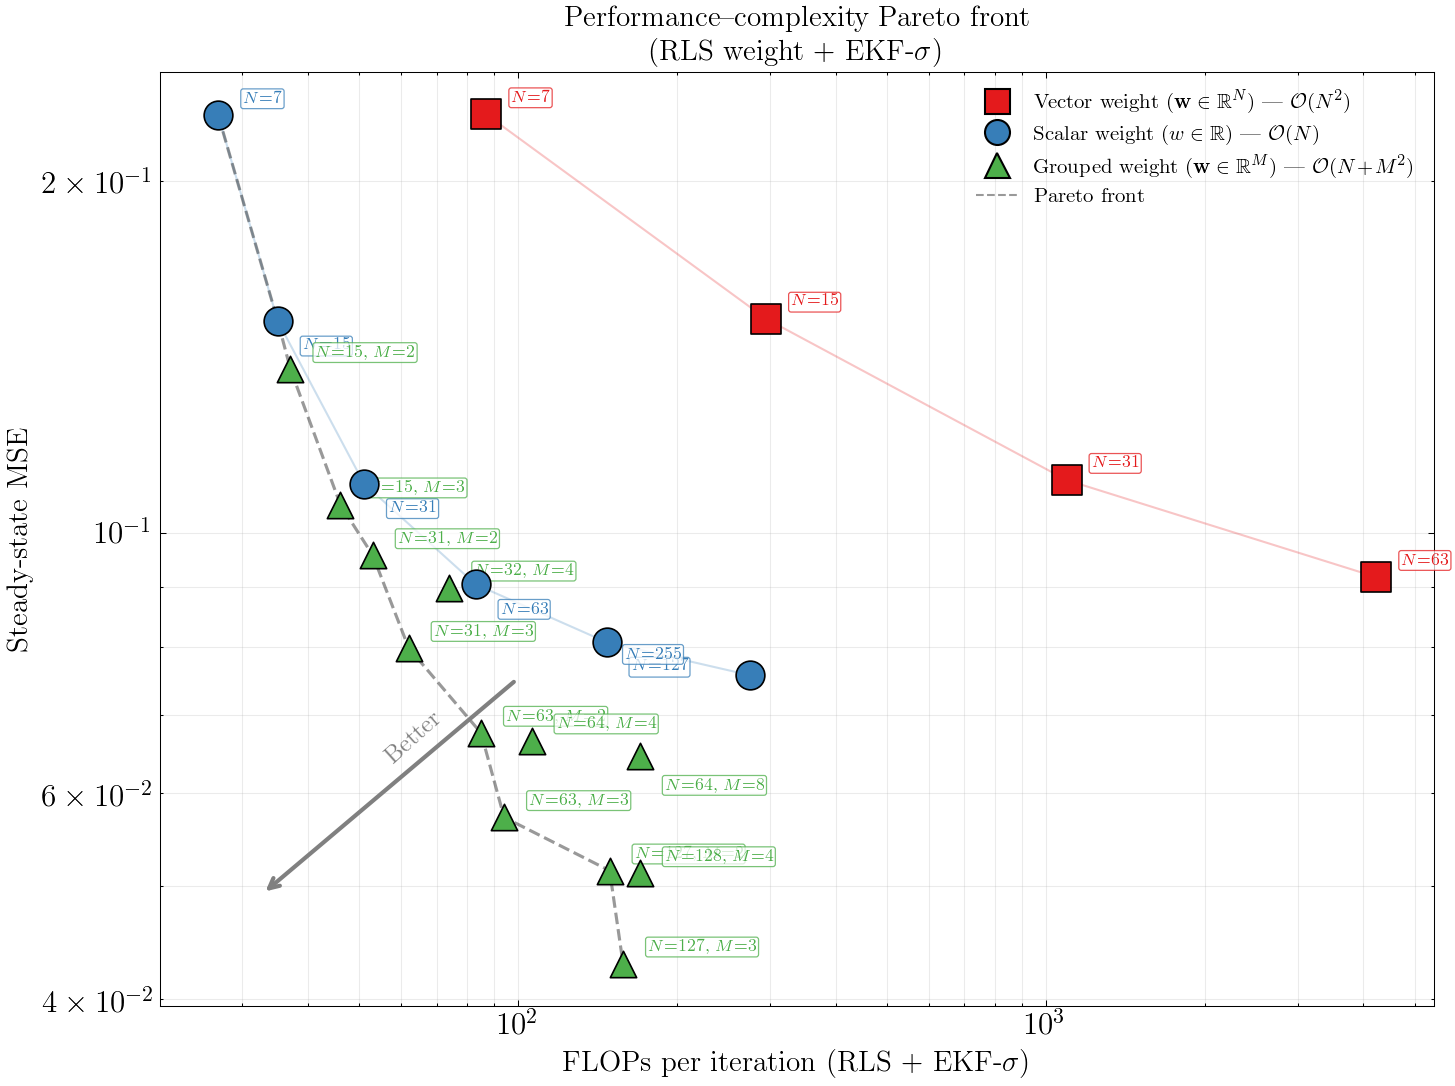

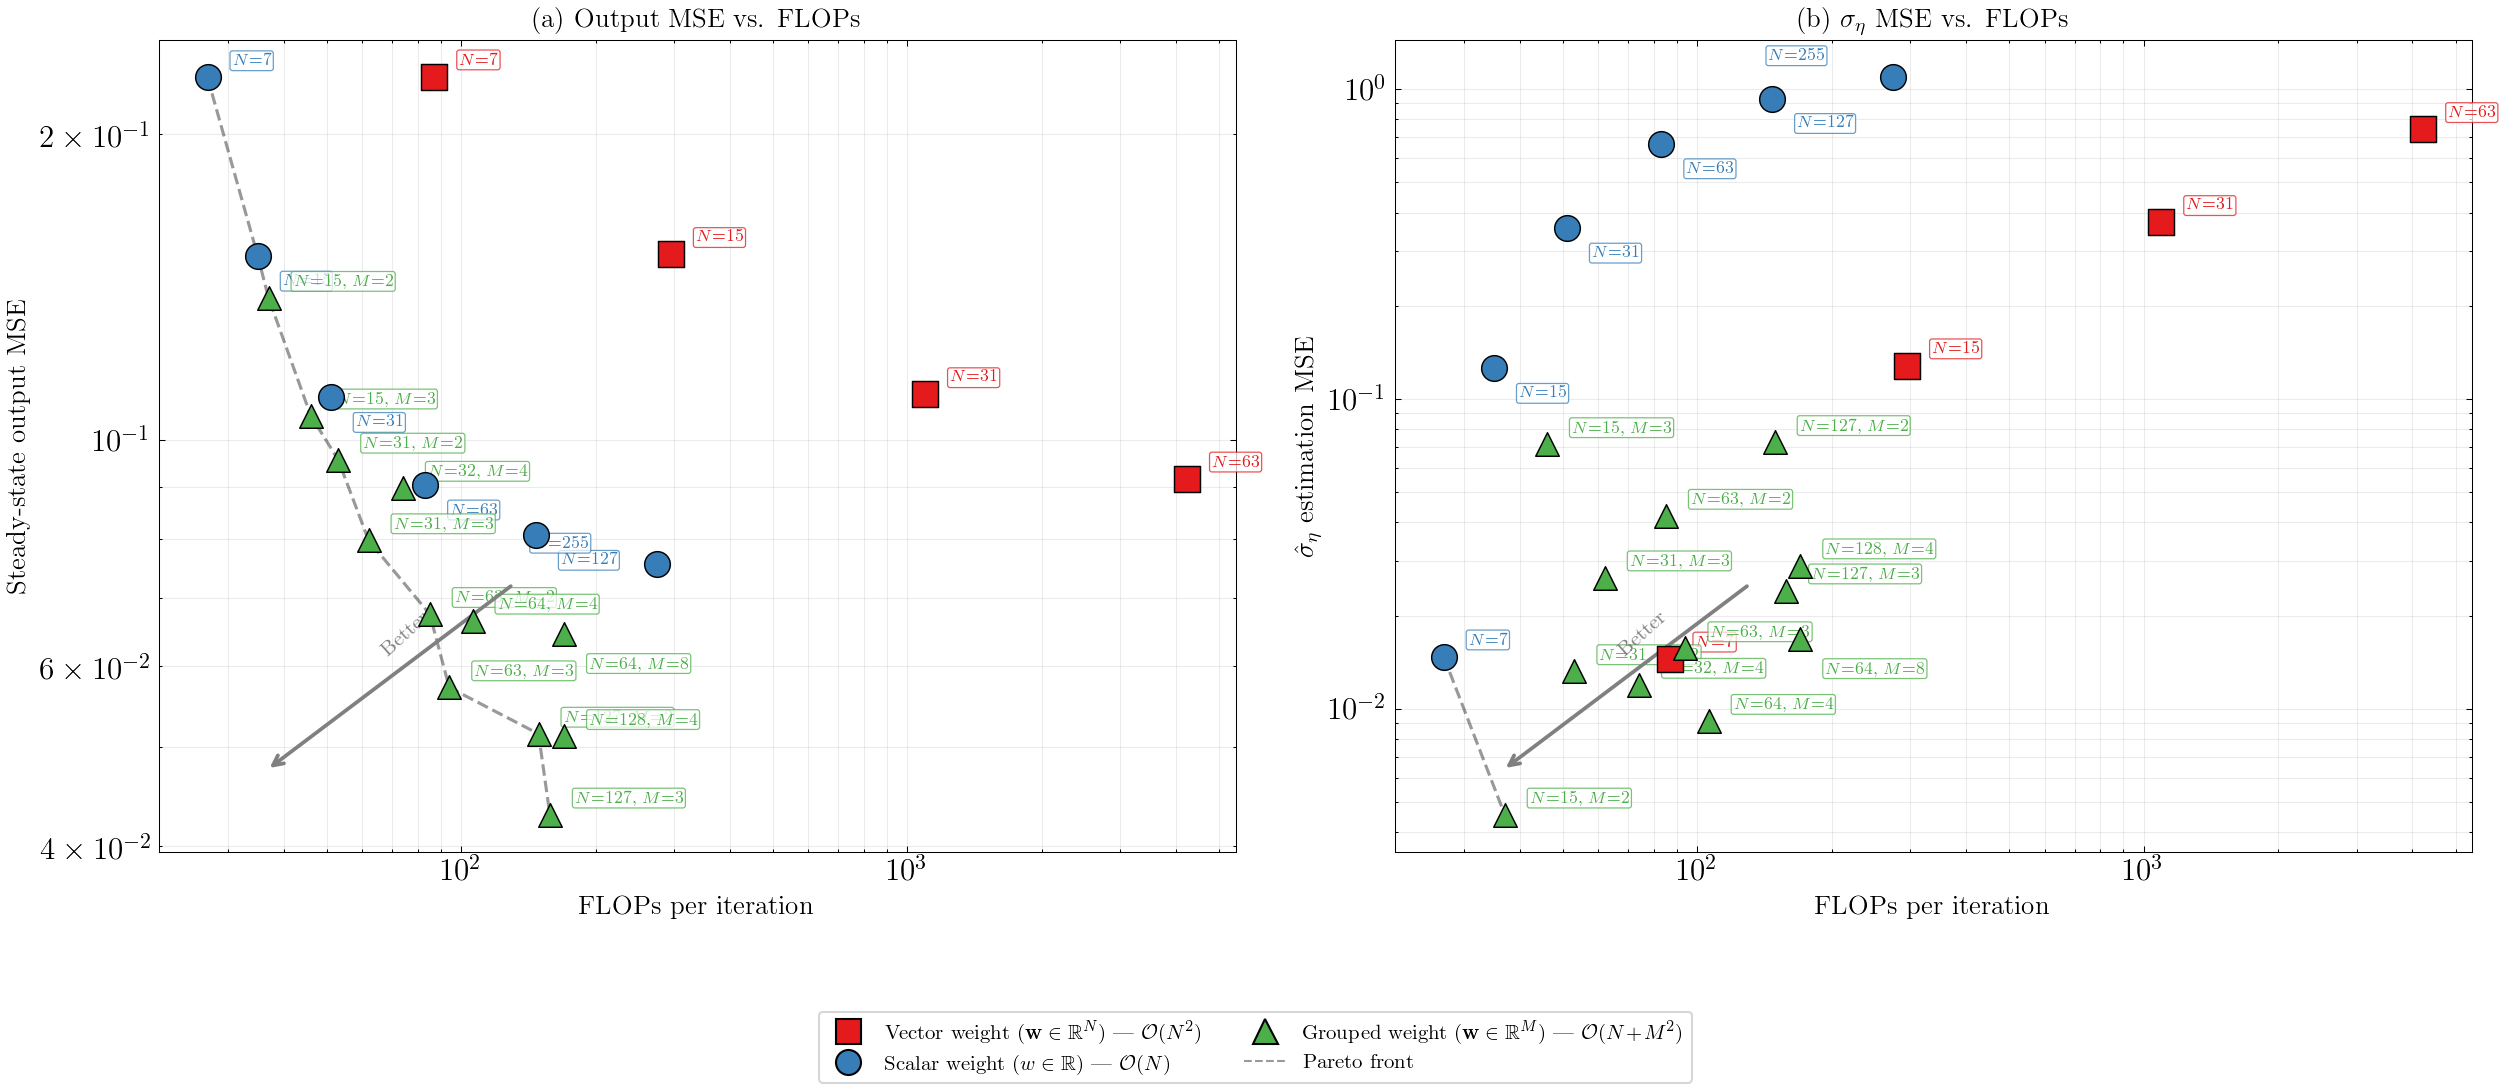

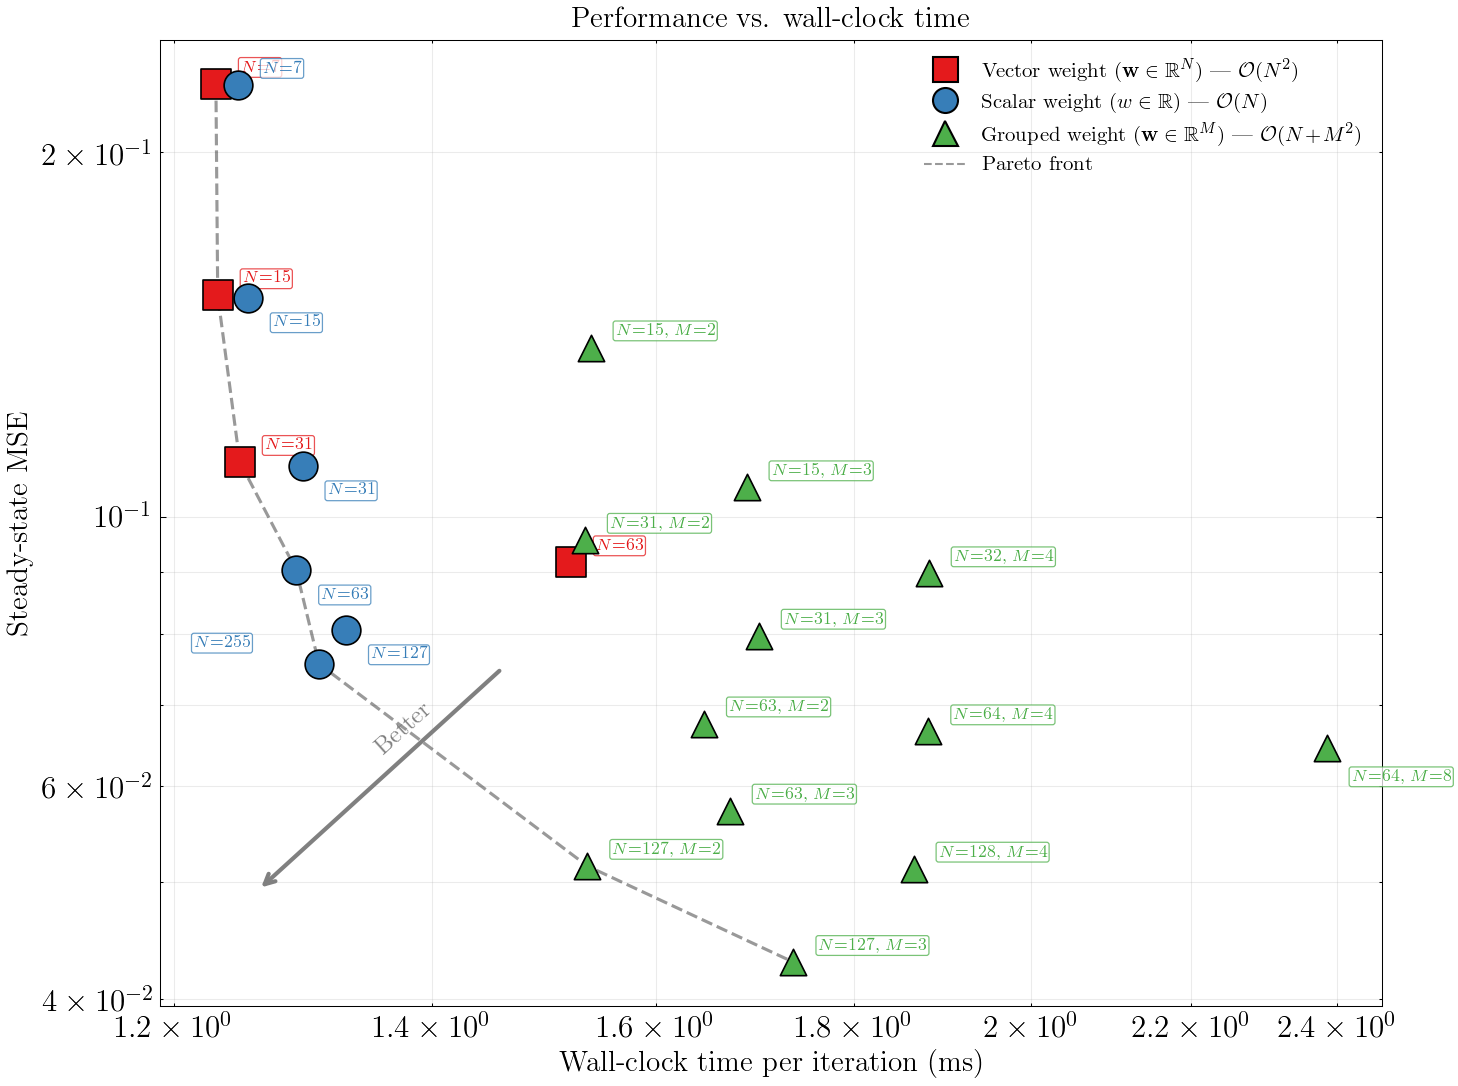

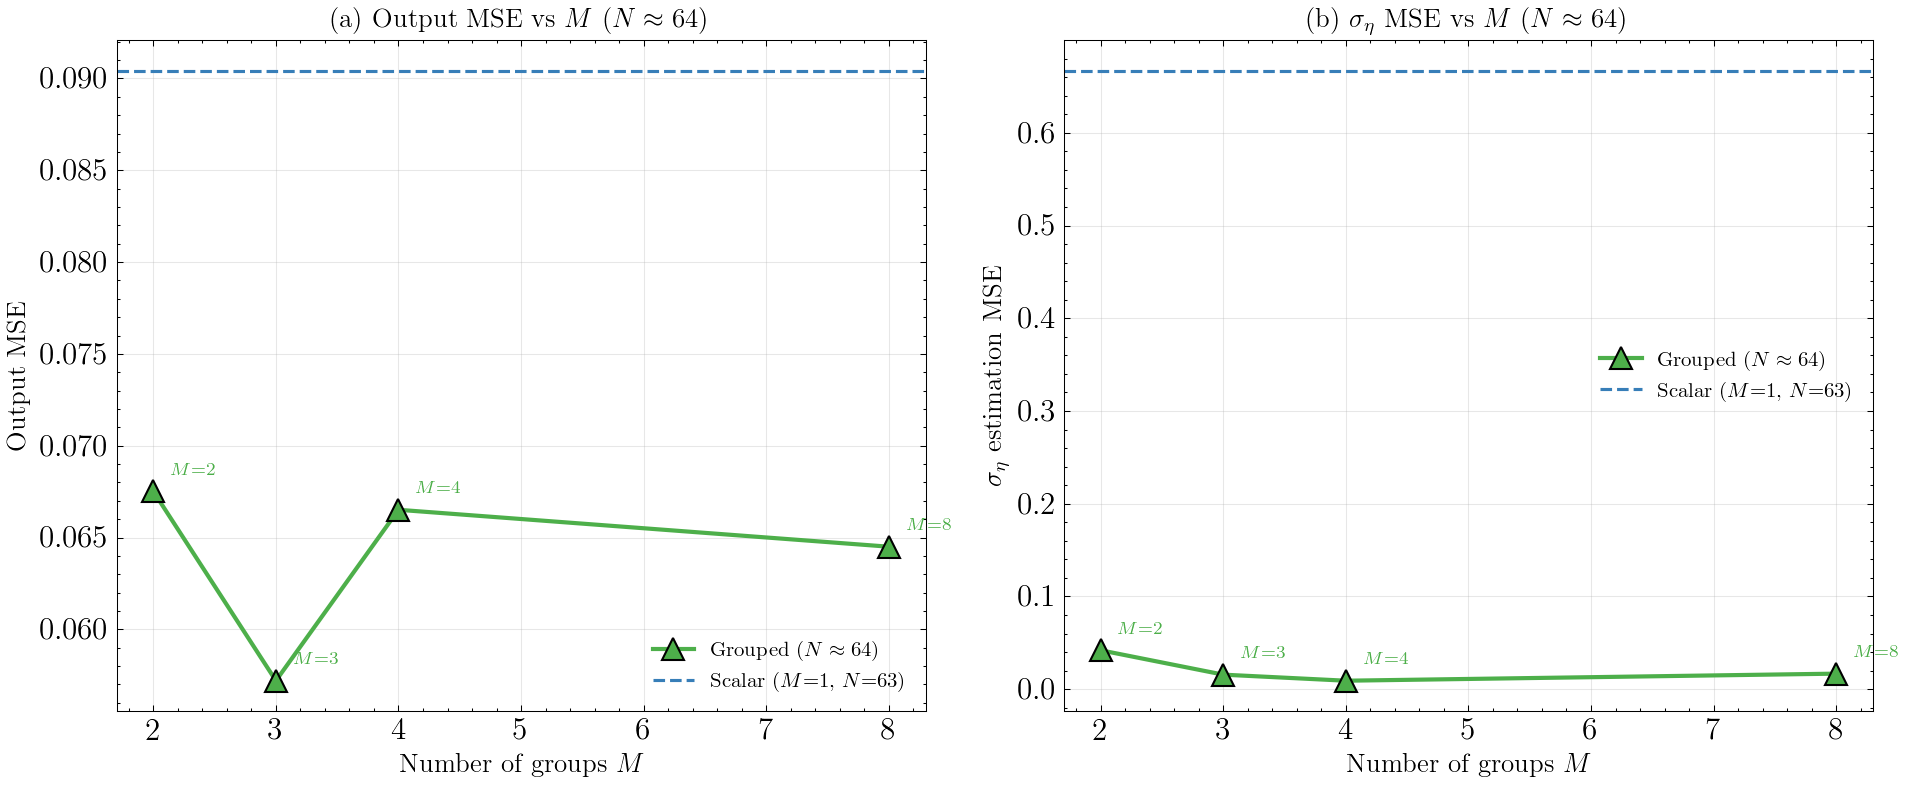

In [6]:
"""
Pareto Front Plotting Script (v2)
==================================
- Every marker labeled with N (and M for grouped)
- Saves EPS + PNG to D:\IEEE 2025 Adaptive weighted SSR\

Usage:
  1. First run: python pareto_experiment.py
  2. Then run:  python plot_pareto.py
"""

import torch
import numpy as np
import os
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'mathtext.fontset': 'stix',
})

# Output directory
SAVE_DIR = r'D:\IEEE 2025 Adaptive weighted SSR'
os.makedirs(SAVE_DIR, exist_ok=True)

# ====================================================================
# Load results
# ====================================================================
data = torch.load('pareto_results.pt', weights_only=False)
results = data['results']

print("Loaded results:")
for r in results:
    print(f"  {r[0]:<8} {r[1]:<22} MSE={r[5]:.6f}  sig_MSE={r[6]:.6f}  FLOPs={r[7]}")

# ====================================================================
# Common style
# ====================================================================
style = {
    'vector':  {'c': '#e41a1c', 'mk': 's', 'sz': 200},
    'scalar':  {'c': '#377eb8', 'mk': 'o', 'sz': 190},
    'grouped': {'c': '#4daf4a', 'mk': '^', 'sz': 160},
}

legend_handles = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#e41a1c',
           markersize=12, markeredgecolor='k',
           label=r'Vector weight ($\mathbf{w}\in\mathbb{R}^N$) — $\mathcal{O}(N^2)$'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#377eb8',
           markersize=12, markeredgecolor='k',
           label=r'Scalar weight ($w\in\mathbb{R}$) — $\mathcal{O}(N)$'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='#4daf4a',
           markersize=12, markeredgecolor='k',
           label=r'Grouped weight ($\mathbf{w}\in\mathbb{R}^M$) — $\mathcal{O}(N\!+\!M^2)$'),
    Line2D([0], [0], linestyle='--', color='k', alpha=0.4, label='Pareto front'),
]


def compute_pareto(pts):
    """Given (x, y) list, return Pareto front (lower-left dominant)."""
    pareto = []
    min_y = float('inf')
    for px, py in sorted(pts):
        if py < min_y:
            pareto.append((px, py))
            min_y = py
    return pareto


def make_label(alg, N, wd):
    """Build annotation text: 'N=xx' or 'N=xx,M=xx'."""
    if alg == 'grouped':
        return f'$N$={N}, $M$={wd}'
    else:
        return f'$N$={N}'


def annotate_all_flops(ax, results, use_sigma=False):
    """Label EVERY marker with N (and M for grouped), FLOPs axis."""
    placed = []  # track positions to avoid overlap

    for alg, label, N, wd, t, mse, smse, fl in results:
        yval = smse if use_sigma else mse
        s = style[alg]
        tc = s['c']
        txt = make_label(alg, N, wd)

        # Default offsets per algorithm type
        if alg == 'vector':
            ox, oy = 12, 6
        elif alg == 'scalar':
            ox, oy = 12, -14
            if N == 7:
                ox, oy = 12, 6
            elif N == 255:
                ox, oy = -60, 8
        else:  # grouped
            ox, oy = 12, 6
            if wd >= 8:
                ox, oy = 12, -16

        ax.annotate(txt, (fl, yval), textcoords='offset points',
                    xytext=(ox, oy), fontsize=8, color=tc, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.15', fc='white',
                              ec=tc, alpha=0.75, lw=0.6))


def annotate_all_time(ax, results):
    """Label EVERY marker with N (and M for grouped), time axis."""
    for alg, label, N, wd, t, mse, smse, fl in results:
        s = style[alg]
        tc = s['c']
        txt = make_label(alg, N, wd)

        if alg == 'vector':
            ox, oy = 12, 6
        elif alg == 'scalar':
            ox, oy = 12, -14
            if N == 7:
                ox, oy = 12, 6
            elif N == 255:
                ox, oy = -60, 8
        else:
            ox, oy = 12, 6
            if wd >= 8:
                ox, oy = 12, -16

        ax.annotate(txt, (t * 1e3, mse), textcoords='offset points',
                    xytext=(ox, oy), fontsize=8, color=tc, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.15', fc='white',
                              ec=tc, alpha=0.75, lw=0.6))


# ====================================================================
# Figure 1: Single-panel Pareto (FLOPs vs output MSE) — for paper
# ====================================================================
fig1, ax1 = plt.subplots(1, 1, figsize=(10, 7.5))

for alg, label, N, wd, t, mse, smse, fl in results:
    s = style[alg]
    ax1.scatter(fl, mse, s=s['sz'], c=s['c'], marker=s['mk'],
                zorder=5, edgecolors='k', linewidths=0.8)

# Connect same-type points with thin lines
for atype, ac in [('vector', '#e41a1c'), ('scalar', '#377eb8')]:
    pts = sorted([(fl, mse) for a, l, N, wd, t, mse, sm, fl in results if a == atype])
    if len(pts) > 1:
        ax1.plot(*zip(*pts), '-', color=ac, alpha=0.25, lw=1)

# Annotate every marker
annotate_all_flops(ax1, results, use_sigma=False)

# Pareto front
pareto = compute_pareto([(fl, mse) for _, _, _, _, _, mse, _, fl in results])
if len(pareto) > 1:
    ax1.plot(*zip(*pareto), 'k--', alpha=0.4, lw=1.5, zorder=3)

# "Better" arrow
ax1.annotate('', xy=(0.08, 0.12), xycoords='axes fraction',
             xytext=(0.28, 0.35), textcoords='axes fraction',
             arrowprops=dict(arrowstyle='->', color='gray', lw=2))
ax1.text(0.20, 0.26, 'Better', transform=ax1.transAxes, fontsize=12,
         color='gray', ha='center', rotation=42, fontstyle='italic')

ax1.legend(handles=legend_handles, loc='upper right', fontsize=10)
ax1.set_xlabel('FLOPs per iteration (RLS + EKF-$\\sigma$)', fontsize=14)
ax1.set_ylabel('Steady-state MSE', fontsize=14)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_title('Performance–complexity Pareto front\n'
              '(RLS weight + EKF-$\\sigma$)', fontsize=14)
ax1.grid(True, alpha=0.25, which='both')

plt.tight_layout()
f1 = os.path.join(SAVE_DIR, 'fig_pareto_flops_mse.eps')

print(f"Saved: {f1}")


# ====================================================================
# Figure 2: Dual-panel (Output MSE + σ MSE)
# ====================================================================
fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(17, 7))

for ax, use_sig, ylabel, title in [
    (ax2a, False, 'Steady-state output MSE', '(a) Output MSE vs. FLOPs'),
    (ax2b, True, r'$\hat{\sigma}_\eta$ estimation MSE', r'(b) $\sigma_\eta$ MSE vs. FLOPs'),
]:
    for alg, label, N, wd, t, mse, smse, fl in results:
        yval = smse if use_sig else mse
        s = style[alg]
        ax.scatter(fl, yval, s=s['sz'] * 0.8, c=s['c'], marker=s['mk'],
                   zorder=5, edgecolors='k', linewidths=0.7)

    annotate_all_flops(ax, results, use_sigma=use_sig)

    par = compute_pareto([(fl, smse if use_sig else mse)
                          for _, _, _, _, _, mse, smse, fl in results])
    if len(par) > 1:
        ax.plot(*zip(*par), 'k--', alpha=0.4, lw=1.5, zorder=3)

    ax.set_xlabel('FLOPs per iteration', fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(title, fontsize=13)
    ax.grid(True, alpha=0.25, which='both')

    ax.annotate('', xy=(0.10, 0.10), xycoords='axes fraction',
                xytext=(0.33, 0.33), textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.8))
    ax.text(0.23, 0.24, 'Better', transform=ax.transAxes, fontsize=10,
            color='gray', ha='center', rotation=42, fontstyle='italic')

fig2.legend(handles=legend_handles, loc='lower center', ncol=2, fontsize=10,
            bbox_to_anchor=(0.5, -0.06), frameon=True)
plt.tight_layout(rect=[0, 0.08, 1, 1])
f2 = os.path.join(SAVE_DIR, 'fig_pareto_dual.eps')

print(f"Saved: {f2}")


# ====================================================================
# Figure 3: Wall-clock time vs MSE
# ====================================================================
fig3, ax3 = plt.subplots(1, 1, figsize=(10, 7.5))

for alg, label, N, wd, t, mse, smse, fl in results:
    s = style[alg]
    ax3.scatter(t * 1e3, mse, s=s['sz'], c=s['c'], marker=s['mk'],
                zorder=5, edgecolors='k', linewidths=0.8)

annotate_all_time(ax3, results)

par_t = compute_pareto([(t * 1e3, mse) for _, _, _, _, t, mse, _, _ in results])
if len(par_t) > 1:
    ax3.plot(*zip(*par_t), 'k--', alpha=0.4, lw=1.5, zorder=3)

ax3.annotate('', xy=(0.08, 0.12), xycoords='axes fraction',
             xytext=(0.28, 0.35), textcoords='axes fraction',
             arrowprops=dict(arrowstyle='->', color='gray', lw=2))
ax3.text(0.20, 0.26, 'Better', transform=ax3.transAxes, fontsize=12,
         color='gray', ha='center', rotation=42, fontstyle='italic')

ax3.legend(handles=legend_handles, loc='upper right', fontsize=10)
ax3.set_xlabel('Wall-clock time per iteration (ms)', fontsize=14)
ax3.set_ylabel('Steady-state MSE', fontsize=14)
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_title('Performance vs. wall-clock time', fontsize=14)
ax3.grid(True, alpha=0.25, which='both')

plt.tight_layout()
f3 = os.path.join(SAVE_DIR, 'fig_pareto_time_mse.eps')

print(f"Saved: {f3}")


# ====================================================================
# Figure 4: Grouped sweep — MSE vs M (N≈64)
# ====================================================================
grp_N64 = [(wd, mse, smse, fl) for a, l, N, wd, t, mse, smse, fl in results
            if a == 'grouped' and N in [63, 64]]
scalar_N63 = [(mse, smse) for a, l, N, wd, t, mse, smse, fl in results
               if a == 'scalar' and N in [63]]

if grp_N64:
    fig4, (a4a, a4b) = plt.subplots(1, 2, figsize=(13, 5.5))
    Ms = [r[0] for r in grp_N64]
    MSEs = [r[1] for r in grp_N64]
    SMSEs = [r[2] for r in grp_N64]

    a4a.plot(Ms, MSEs, '^-', color='#4daf4a', markersize=11, lw=2,
             markeredgecolor='k', label=f'Grouped ($N \\approx 64$)')
    a4b.plot(Ms, SMSEs, '^-', color='#4daf4a', markersize=11, lw=2,
             markeredgecolor='k', label=f'Grouped ($N \\approx 64$)')

    for m_val, mse_val, smse_val, _ in grp_N64:
        a4a.annotate(f'$M$={m_val}', (m_val, mse_val), textcoords='offset points',
                     xytext=(8, 8), fontsize=9, color='#4daf4a', fontweight='bold')
        a4b.annotate(f'$M$={m_val}', (m_val, smse_val), textcoords='offset points',
                     xytext=(8, 8), fontsize=9, color='#4daf4a', fontweight='bold')

    if scalar_N63:
        a4a.axhline(scalar_N63[0][0], color='#377eb8', ls='--', lw=1.5,
                     label='Scalar ($M$=1, $N$=63)')
        a4b.axhline(scalar_N63[0][1], color='#377eb8', ls='--', lw=1.5,
                     label='Scalar ($M$=1, $N$=63)')

    a4a.set_xlabel('Number of groups $M$', fontsize=13)
    a4a.set_ylabel('Output MSE', fontsize=13)
    a4a.set_title(r'(a) Output MSE vs $M$ ($N \approx 64$)', fontsize=13)
    a4a.legend(fontsize=10)
    a4a.grid(True, alpha=0.3)

    a4b.set_xlabel('Number of groups $M$', fontsize=13)
    a4b.set_ylabel(r'$\sigma_\eta$ estimation MSE', fontsize=13)
    a4b.set_title(r'(b) $\sigma_\eta$ MSE vs $M$ ($N \approx 64$)', fontsize=13)
    a4b.legend(fontsize=10)
    a4b.grid(True, alpha=0.3)

    plt.tight_layout()
    f4 = os.path.join(SAVE_DIR, 'fig_grouped_sweep.eps')

    print(f"Saved: {f4}")

print(f"\n=== All EPS + PNG figures saved to: {SAVE_DIR} ===")

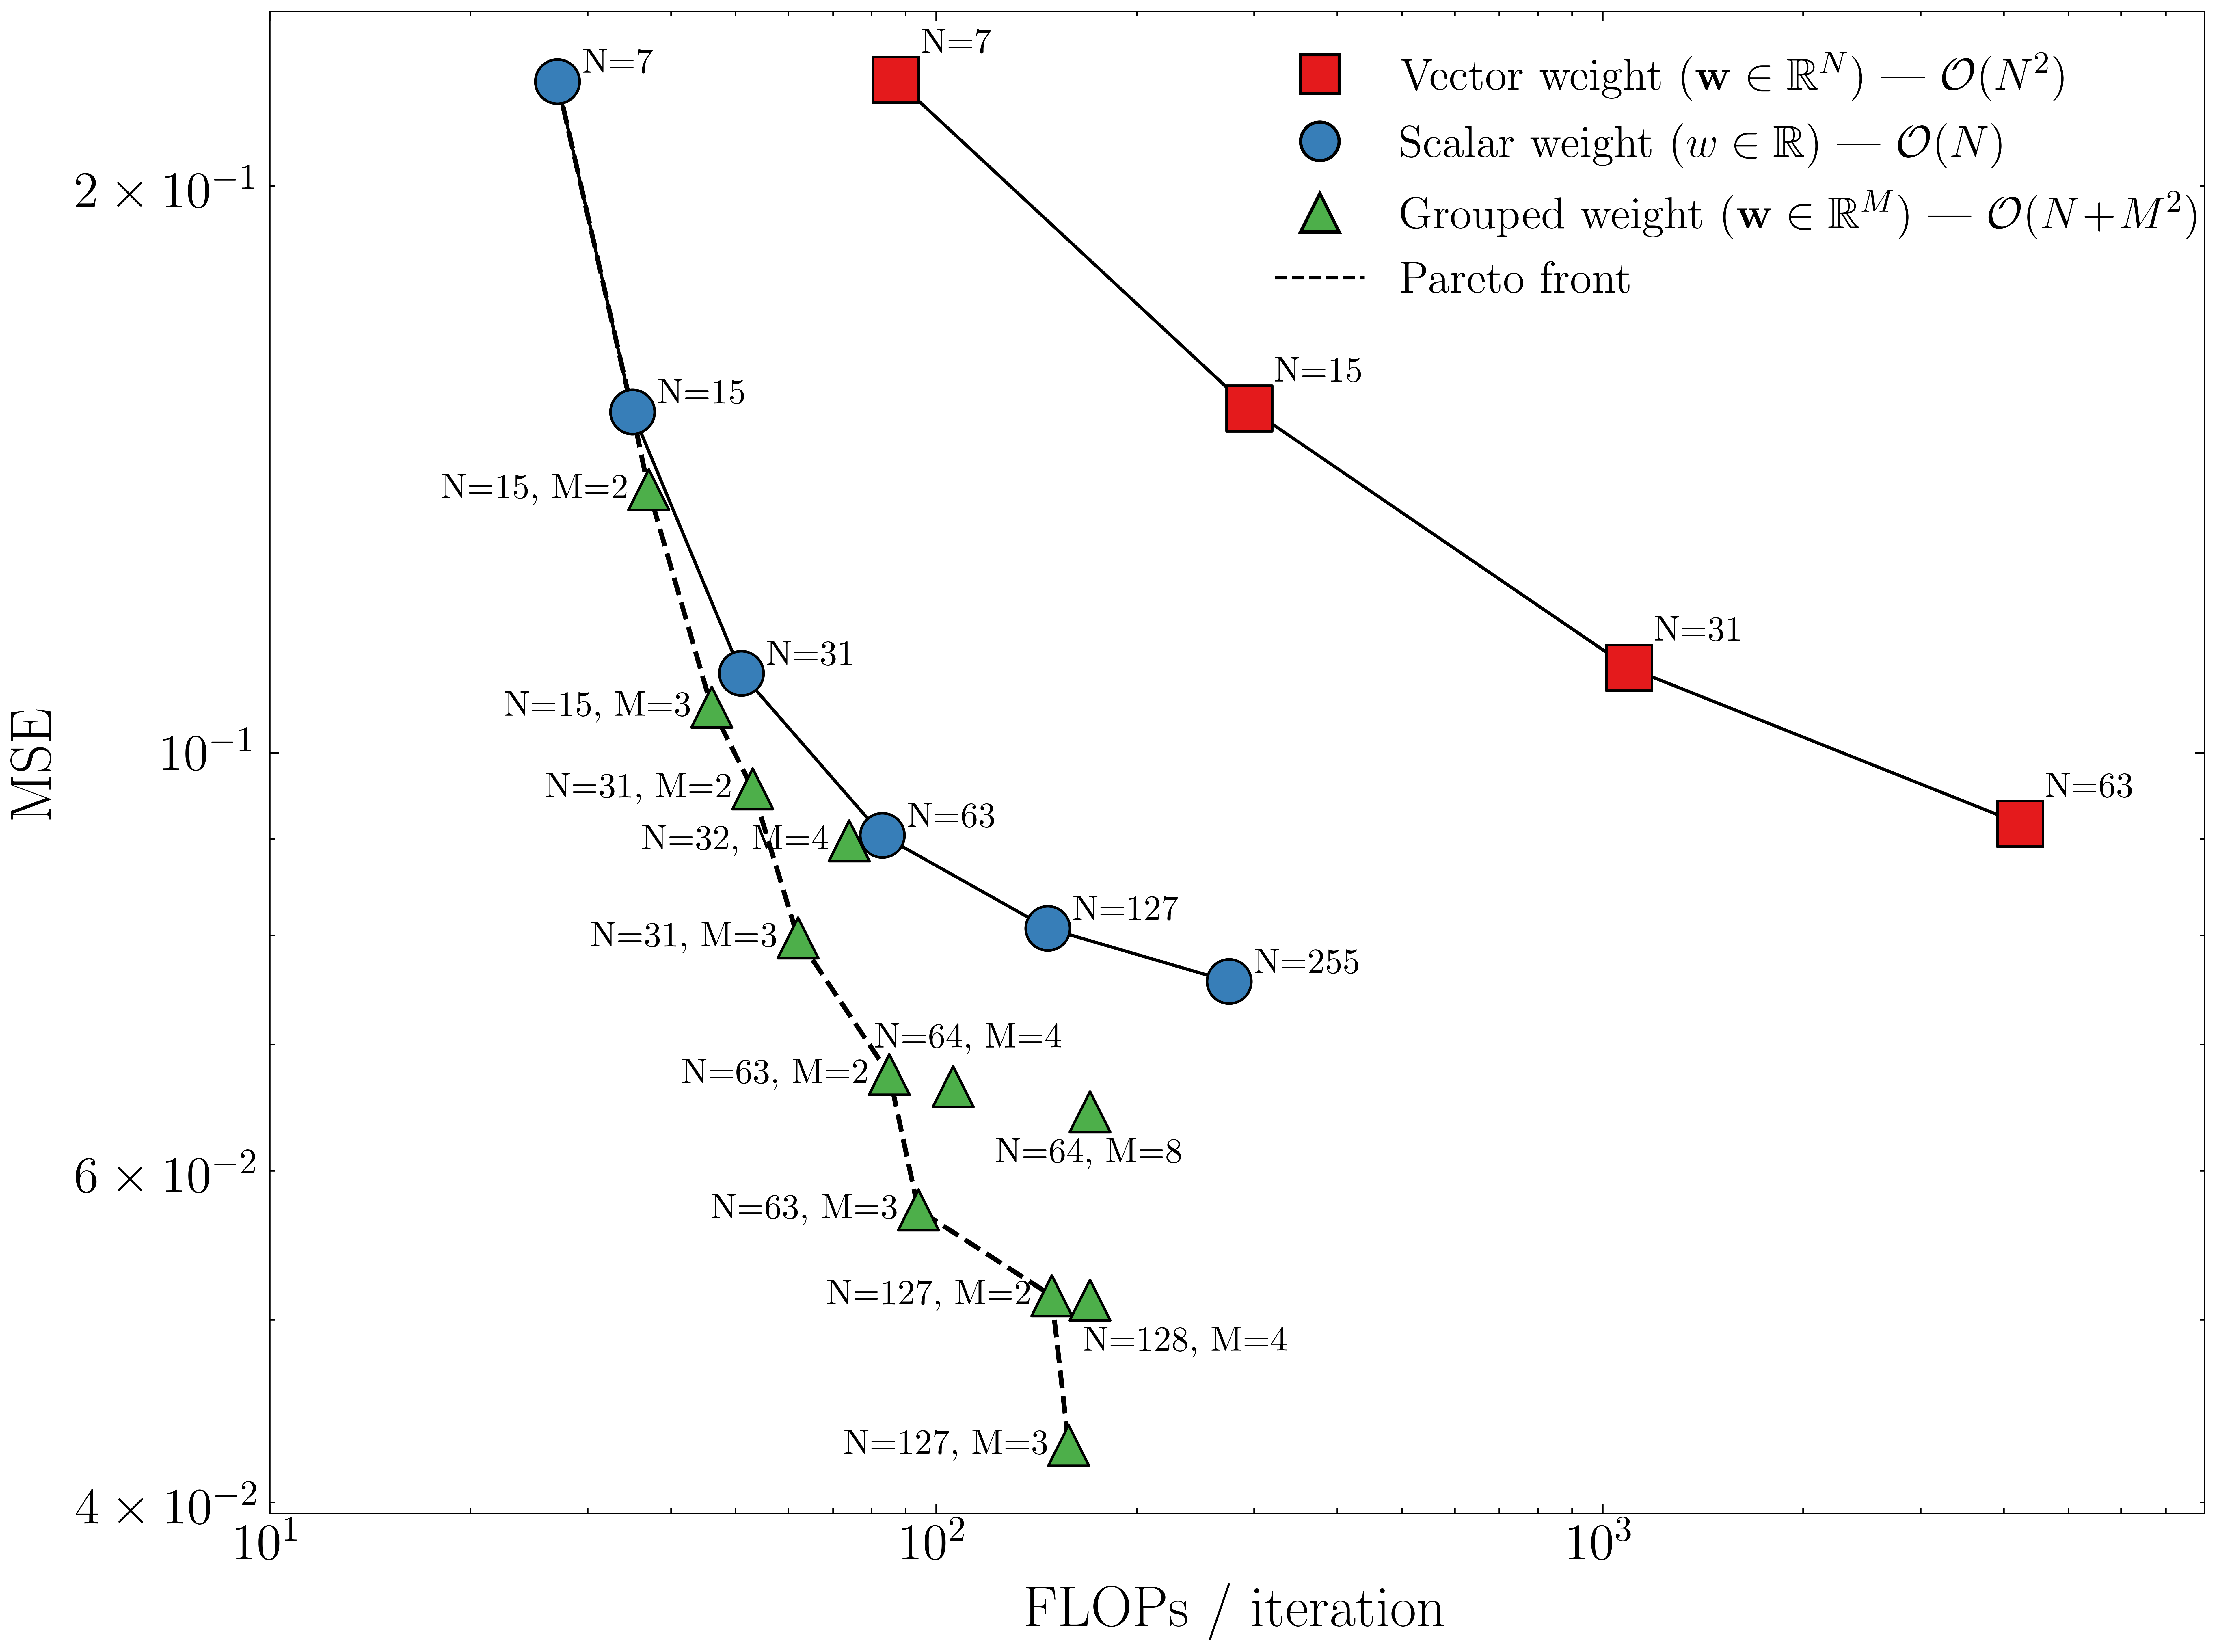

In [10]:
# =========================================================
# Imports
# =========================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
#import scienceplots   # 需要 pip install SciencePlots

# =========================================================
# Global plotting style (IEEE + Science)
# =========================================================
plt.style.use(['science', 'ieee'])

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'font.size': 15,
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 15,
})

mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False


# =========================================================
# Example SAVE_DIR (modify if needed)
# =========================================================
SAVE_DIR = './'
os.makedirs(SAVE_DIR, exist_ok=True)

legend_handles = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#e41a1c',
           markersize=12, markeredgecolor='k',
           label=r'Vector weight ($\mathbf{w}\in\mathbb{R}^N$) — $\mathcal{O}(N^2)$'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#377eb8',
           markersize=12, markeredgecolor='k',
           label=r'Scalar weight ($w\in\mathbb{R}$) — $\mathcal{O}(N)$'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='#4daf4a',
           markersize=12, markeredgecolor='k',
           label=r'Grouped weight ($\mathbf{w}\in\mathbb{R}^M$) — $\mathcal{O}(N\!+\!M^2)$'),
    Line2D([0], [0], linestyle='--', color='k', label='Pareto front'),
]
# =========================================================
# Plot Pareto Figure
# =========================================================
fig1, ax1 = plt.subplots(1, 1, figsize=(10, 7.5))

# Scatter points
for alg, label, N, wd, t, mse, smse, fl in results:
    s = style[alg]
    ax1.scatter(
        fl, mse,
        s=s['sz'],
        c=s['c'],
        marker=s['mk'],
        zorder=5,
        edgecolors='k',
        linewidths=0.8
    )

# Connect same-type points
for atype, ac in [('vector', '#e41a1c'), ('scalar', '#377eb8')]:
    pts = sorted([
        (fl, mse)
        for a, l, N, wd, t, mse, sm, fl in results
        if a == atype
    ])
    if len(pts) > 1:
        ax1.plot(*zip(*pts), '-', color='k', lw=1)
        
        

def annotate_all_flops(ax, results, use_sigma=False):

    for alg, label, N, wd, t, mse, smse, fl in results:

        alg_lower = str(alg).lower()

        # ---------------- Vector ----------------
        if alg_lower == 'vector':
            text = f'N={N}'
            offset = (8, 6)
            ha, va = 'left', 'bottom'

        # ---------------- Scalar ----------------
        elif alg_lower == 'scalar':
            text = f'N={N}'
            offset = (8, 10)
            ha, va = 'left', 'top'

        # ---------------- Grouped ----------------
        elif alg_lower == 'grouped':
            M = wd
            text = f'N={N}, M={M}'

            # ---- 特殊点 N=64, M=4 ----
            if N == 64 and M == 4:
                offset = (5, 10)   # 正上方
                ha, va = 'center', 'bottom'
            elif N == 64 and M == 8:
                offset = (0, -18)   # 正上方
                ha, va = 'center', 'bottom'
            elif N == 128 and M == 4:
                offset = (30, -18)   # 正上方
                ha, va = 'center', 'bottom'
            else:
                offset = (-6, 0)  # 左侧
                ha, va = 'right', 'center'

        else:
            text = f'N={N}'
            offset = (6, 6)
            ha, va = 'left', 'bottom'

        ax.annotate(
            text,
            xy=(fl, mse),
            xytext=offset,
            textcoords='offset points',
            fontsize=11,
            ha=ha,
            va=va
        )
# Annotate
annotate_all_flops(ax1, results, use_sigma=False)

# Pareto front
pareto = compute_pareto([(fl, mse) for _, _, _, _, _, mse, _, fl in results])
if len(pareto) > 1:
    ax1.plot(*zip(*pareto), 'k--', lw=1.5)

# Legend and labels
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim([10,8000])
ax1.legend(
    handles=legend_handles,
    loc='upper right',
    bbox_to_anchor=(1.02, 1),  # 向右移动
    fontsize=14
)

ax1.set_xlabel(r'FLOPs / iteration',fontsize=18)
ax1.tick_params(axis='both', which='major', labelsize=16)
ax1.tick_params(axis='both', which='minor', labelsize=16)
ax1.set_ylabel('MSE', fontsize=18)
plt.savefig(
    'D:/IEEE 2025 Adaptive weighted SSR/Figpareto.eps',
    format='eps',
    dpi=800,
    bbox_inches='tight'
)
plt.tight_layout()